
# Employee Attrition EDA — IBM HR Analytics Dataset


## 0. Setup

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.3f}".format)

In [0]:
df = spark.table("workspace.bronze.ibm_hr_employee_attrition").toPandas()

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Shape: 1470 rows × 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 1. Schema Overview — Dtypes, Nulls, Uniques

In [0]:
def schema_summary(dataframe):
    summary = pd.DataFrame({
        "dtype": dataframe.dtypes,
        "non_null": dataframe.notnull().sum(),
        "null_count": dataframe.isnull().sum(),
        "null_pct": (dataframe.isnull().sum() / len(dataframe) * 100).round(2),
        "n_unique": dataframe.nunique(),
        "sample_value": dataframe.iloc[0],
    })
    return summary.sort_values("dtype", ascending=True)

schema_summary(df)


,dtype,non_null,null_count,null_pct,n_unique,sample_value
Age,int64,1470,0,0.000,43,41
YearsInCurrentRole,int64,1470,0,0.000,19,4
YearsAtCompany,int64,1470,0,0.000,37,6
WorkLifeBalance,int64,1470,0,0.000,4,1
TrainingTimesLastYear,int64,1470,0,0.000,7,0
TotalWorkingYears,int64,1470,0,0.000,40,8
StockOptionLevel,int64,1470,0,0.000,4,0
StandardHours,int64,1470,0,0.000,1,80
RelationshipSatisfaction,int64,1470,0,0.000,4,1
PerformanceRating,int64,1470,0,0.000,2,3


#  --- Duplicates ---

In [0]:
n_dupes = df.duplicated().sum()
n_dupes_by_empno = df.duplicated(subset=["EmployeeNumber"]).sum()
print(f"Full-row duplicates:       {n_dupes}")
print(f"Duplicate EmployeeNumber:  {n_dupes_by_empno}")

Full-row duplicates:       0
Duplicate EmployeeNumber:  0


## 2. Target Variable — Attrition

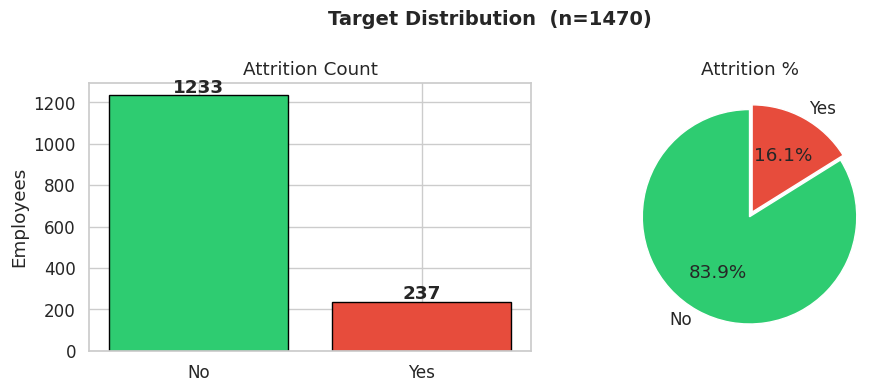


Attrition rate: 16.1%  (237 / 1470)
→ Imbalanced dataset — will need stratified splits + class weighting in ML


In [0]:
target_counts = df["Attrition"].value_counts()
target_pct = df["Attrition"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
axes[0].bar(target_counts.index, target_counts.values, color=["#2ecc71", "#e74c3c"], edgecolor="black")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 15, str(v), ha="center", fontweight="bold")
axes[0].set_title("Attrition Count")
axes[0].set_ylabel("Employees")

# Percentage
axes[1].pie(
    target_pct.values, labels=target_pct.index, autopct="%1.1f%%",
    colors=["#2ecc71", "#e74c3c"], startangle=90, explode=[0, 0.05]
)
axes[1].set_title("Attrition %")

plt.suptitle(f"Target Distribution  (n={len(df)})", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nAttrition rate: {target_pct.get('Yes', 0):.1f}%  ({target_counts.get('Yes', 0)} / {len(df)})")
print("→ Imbalanced dataset — will need stratified splits + class weighting in ML")


In [0]:
# Binary encode for downstream analysis
df["Attrition_Flag"] = (df["Attrition"] == "Yes").astype(int)

## 3. Constant / Near-Constant Columns

In [0]:
constant_cols = []
for col in df.columns:
    n_unique = df[col].nunique()
    if n_unique <= 1:
        constant_cols.append((col, n_unique, df[col].iloc[0]))
    elif n_unique == 2 and df[col].dtype == "object":
        vals = df[col].value_counts()
        if vals.iloc[1] / len(df) < 0.01:  # <1% minority
            constant_cols.append((col, n_unique, f"{vals.index[0]} dominates"))

print("Columns to DROP (constant or near-constant):\n")
for col, nu, val in constant_cols:
    print(f"  {col:25s}  unique={nu}  value={val}")

# Verify known constants from IBM dataset
for col in ["EmployeeCount", "Over18", "StandardHours"]:
    print(f"\n{col}: unique values = {df[col].unique()}")

Columns to DROP (constant or near-constant):

  EmployeeCount              unique=1  value=1
  Over18                     unique=1  value=Y
  StandardHours              unique=1  value=80

EmployeeCount: unique values = [1]

Over18: unique values = ['Y']

StandardHours: unique values = [80]


## 4. Numeric Features — Distributions + Correlation with Attrition

In [0]:
# Separate numeric and categorical
cols_to_exclude = ["EmployeeCount", "StandardHours", "EmployeeNumber", "Attrition_Flag"]
numeric_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns if c not in cols_to_exclude
]
cat_cols = [
    c for c in df.select_dtypes(include=["object"]).columns if c not in ["Attrition", "Over18"]
]

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(cat_cols)}")


Numeric features: 23
Categorical features: 7


In [0]:
# --- Descriptive stats ---
df[numeric_cols].describe().T.sort_values("mean", ascending=False)


,count,mean,std,min,25%,50%,75%,max
MonthlyRate,1470.000,14313.103,7117.786,2094.000,8047.000,14235.500,20461.500,26999.000
MonthlyIncome,1470.000,6502.931,4707.957,1009.000,2911.000,4919.000,8379.000,19999.000
DailyRate,1470.000,802.486,403.509,102.000,465.000,802.000,1157.000,1499.000
HourlyRate,1470.000,65.891,20.329,30.000,48.000,66.000,83.750,100.000
Age,1470.000,36.924,9.135,18.000,30.000,36.000,43.000,60.000
PercentSalaryHike,1470.000,15.210,3.660,11.000,12.000,14.000,18.000,25.000
TotalWorkingYears,1470.000,11.280,7.781,0.000,6.000,10.000,15.000,40.000
DistanceFromHome,1470.000,9.193,8.107,1.000,2.000,7.000,14.000,29.000
YearsAtCompany,1470.000,7.008,6.127,0.000,3.000,5.000,9.000,40.000
YearsInCurrentRole,1470.000,4.229,3.623,0.000,2.000,3.000,7.000,18.000


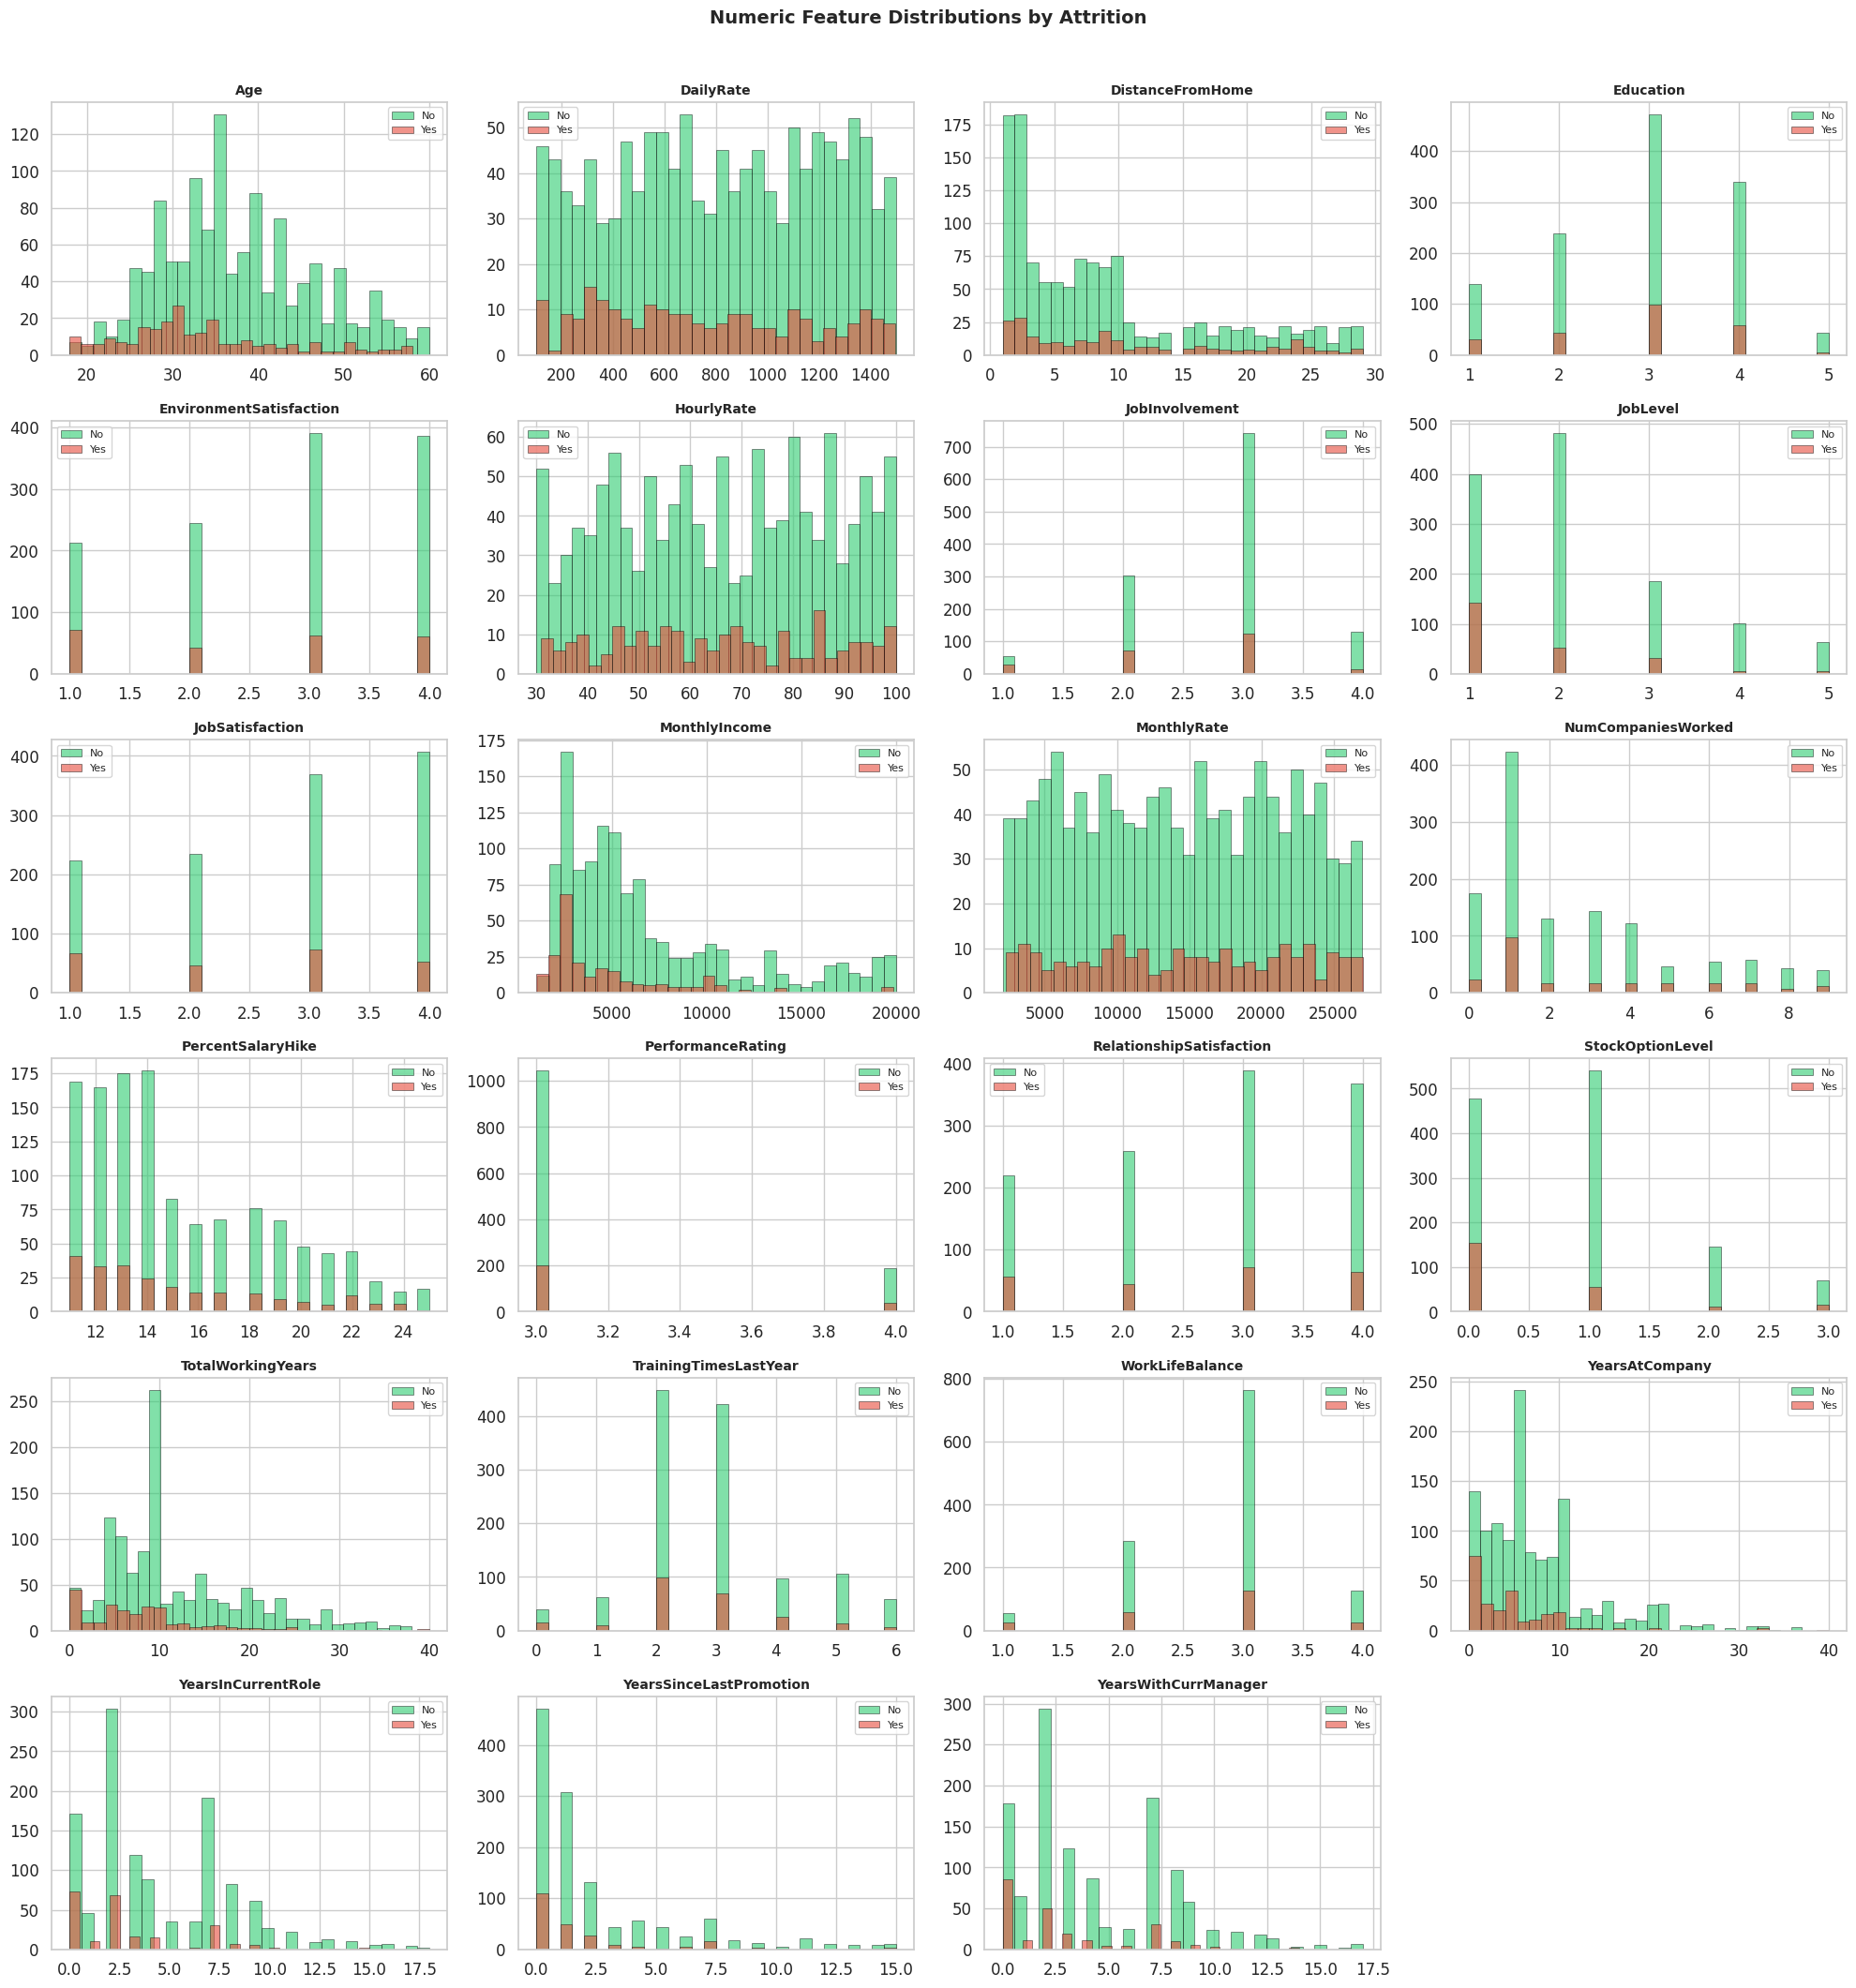

In [0]:
# --- Distribution histograms (all numeric) ---
n_cols_plot = 4
n_rows_plot = int(np.ceil(len(numeric_cols) / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(20, n_rows_plot * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    for label, color in [("No", "#2ecc71"), ("Yes", "#e74c3c")]:
        subset = df[df["Attrition"] == label][col]
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor="black", linewidth=0.5)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions by Attrition", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [0]:
# --- Point-biserial correlation: each numeric feature vs Attrition_Flag ---
correlations = []
for col in numeric_cols:
    valid = df[[col, "Attrition_Flag"]].dropna()
    corr, pval = stats.pointbiserialr(valid["Attrition_Flag"], valid[col])
    correlations.append({"feature": col, "correlation": corr, "abs_corr": abs(corr), "p_value": pval})

corr_df = pd.DataFrame(correlations).sort_values("abs_corr", ascending=False)
corr_df["significant"] = corr_df["p_value"] < 0.05

print("Point-Biserial Correlation with Attrition (sorted by |r|):\n")
print(corr_df.to_string(index=False))

Point-Biserial Correlation with Attrition (sorted by |r|):

                 feature  correlation  abs_corr  p_value  significant
       TotalWorkingYears       -0.171     0.171    0.000         True
                JobLevel       -0.169     0.169    0.000         True
      YearsInCurrentRole       -0.161     0.161    0.000         True
           MonthlyIncome       -0.160     0.160    0.000         True
                     Age       -0.159     0.159    0.000         True
    YearsWithCurrManager       -0.156     0.156    0.000         True
        StockOptionLevel       -0.137     0.137    0.000         True
          YearsAtCompany       -0.134     0.134    0.000         True
          JobInvolvement       -0.130     0.130    0.000         True
         JobSatisfaction       -0.103     0.103    0.000         True
 EnvironmentSatisfaction       -0.103     0.103    0.000         True
        DistanceFromHome        0.078     0.078    0.003         True
         WorkLifeBalance      

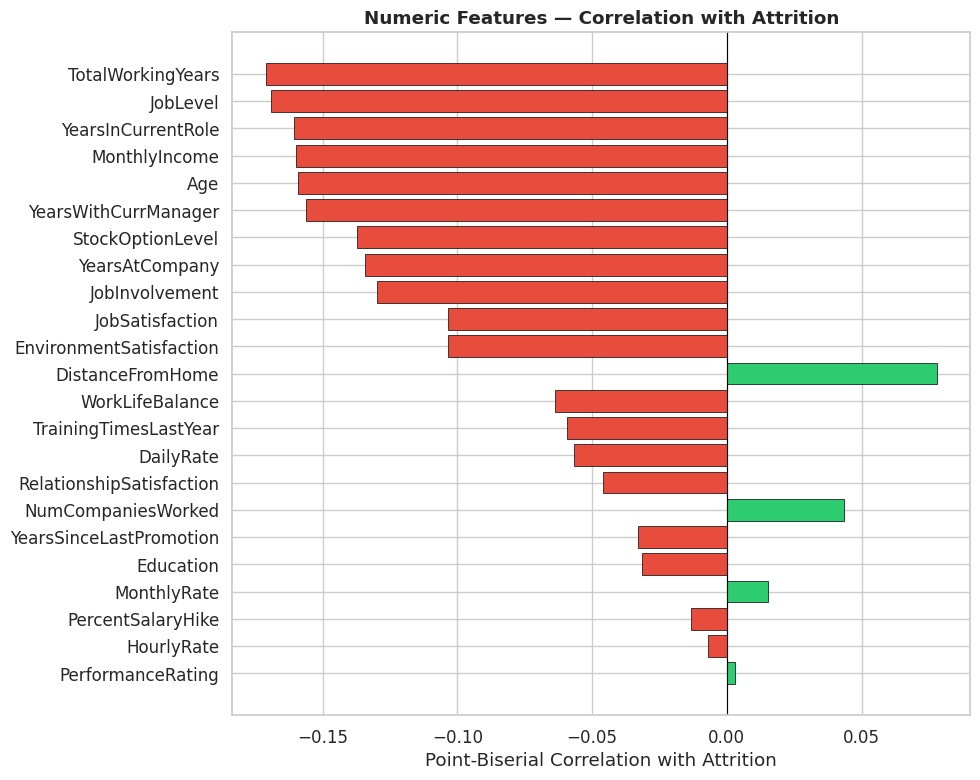

In [0]:
# --- Bar chart of correlations ---
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e74c3c" if c < 0 else "#2ecc71" for c in corr_df["correlation"]]
ax.barh(corr_df["feature"], corr_df["correlation"], color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Point-Biserial Correlation with Attrition")
ax.set_title("Numeric Features — Correlation with Attrition", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Categorical Features — Attrition Rates

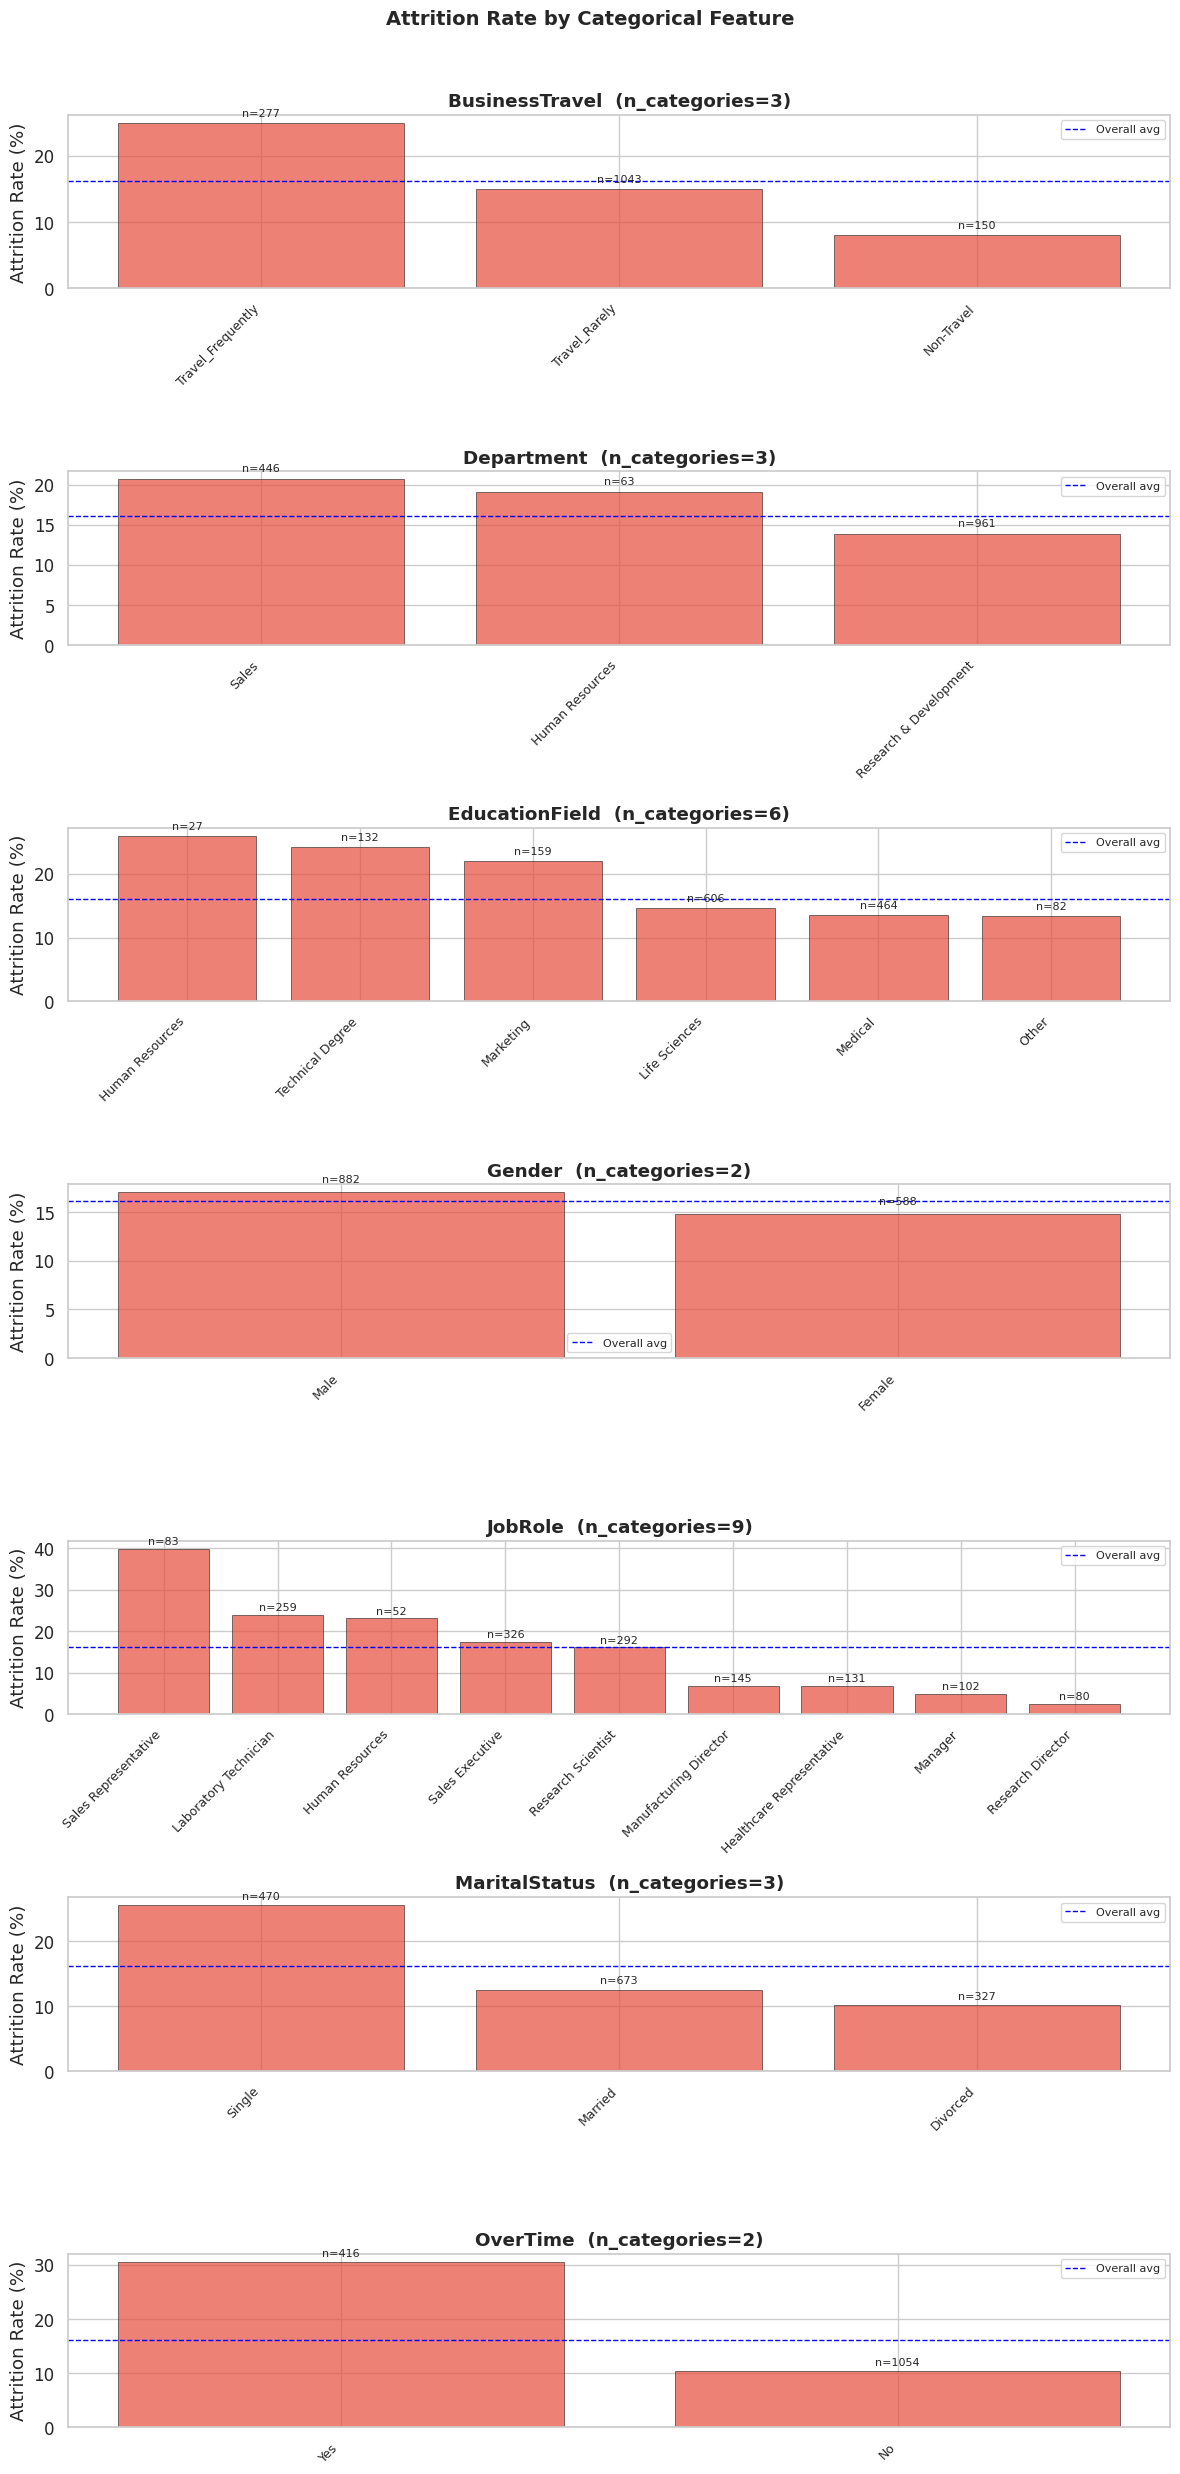

In [0]:
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, len(cat_cols) * 3.5))
if len(cat_cols) == 1:
    axes = [axes]

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    # Compute attrition rate per category
    grouped = df.groupby(col)["Attrition_Flag"].agg(["mean", "count"]).reset_index()
    grouped.columns = [col, "attrition_rate", "count"]
    grouped = grouped.sort_values("attrition_rate", ascending=False)
    
    # Bar chart
    bars = ax.bar(
        range(len(grouped)), grouped["attrition_rate"] * 100,
        color="#e74c3c", alpha=0.7, edgecolor="black", linewidth=0.5
    )
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels(grouped[col], rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Attrition Rate (%)")
    ax.set_title(f"{col}  (n_categories={grouped[col].nunique()})", fontweight="bold")
    ax.axhline(y=df["Attrition_Flag"].mean() * 100, color="blue", linestyle="--", linewidth=1, label="Overall avg")
    
    # Annotate counts
    for j, (rate, count) in enumerate(zip(grouped["attrition_rate"], grouped["count"])):
        ax.text(j, rate * 100 + 1, f"n={count}", ha="center", fontsize=8)
    
    ax.legend(fontsize=8)

plt.suptitle("Attrition Rate by Categorical Feature", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [0]:
# --- Chi-squared test for each categorical feature ---
print("Chi-Squared Test of Independence with Attrition:\n")
print(f"{'Feature':30s} {'Chi2':>10s} {'p-value':>12s} {'Cramers V':>10s} {'Significant':>12s}")
print("-" * 78)

for col in cat_cols:
    ct = pd.crosstab(df[col], df["Attrition"])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k)) if k > 0 else 0
    sig = "YES" if p < 0.05 else "no"
    print(f"{col:30s} {chi2:10.2f} {p:12.6f} {cramers_v:10.3f} {sig:>12s}")


Chi-Squared Test of Independence with Attrition:

Feature                              Chi2      p-value  Cramers V  Significant
------------------------------------------------------------------------------
BusinessTravel                      24.18     0.000006      0.128          YES
Department                          10.80     0.004526      0.086          YES
EducationField                      16.02     0.006774      0.104          YES
Gender                               1.12     0.290572      0.028           no
JobRole                             86.19     0.000000      0.242          YES
MaritalStatus                       46.16     0.000000      0.177          YES
OverTime                            87.56     0.000000      0.244          YES


## 6. Ordinal / Likert-Scale Features — Attrition Rates by Level

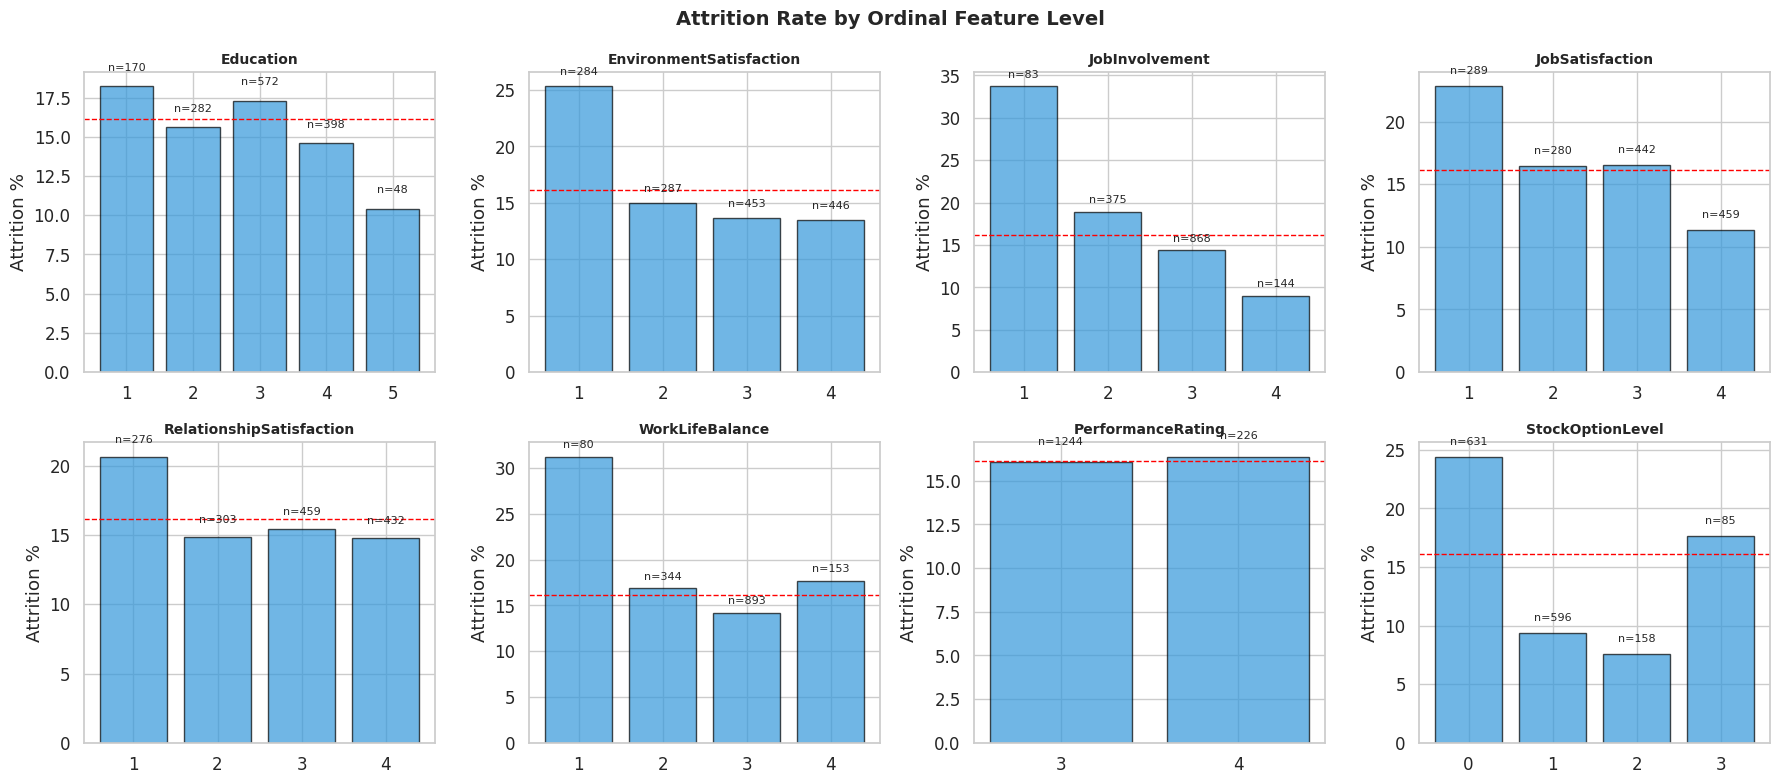

In [0]:
# These columns are numeric but really ordinal (1-4 or 1-5 scales)
ordinal_cols = [
    "Education", "EnvironmentSatisfaction", "JobInvolvement",
    "JobSatisfaction", "RelationshipSatisfaction", "WorkLifeBalance",
    "PerformanceRating", "StockOptionLevel"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(ordinal_cols):
    ax = axes[i]
    grouped = df.groupby(col)["Attrition_Flag"].agg(["mean", "count"]).reset_index()
    grouped.columns = [col, "attrition_rate", "count"]
    
    bars = ax.bar(
        grouped[col].astype(str), grouped["attrition_rate"] * 100,
        color="#3498db", alpha=0.7, edgecolor="black"
    )
    ax.axhline(y=df["Attrition_Flag"].mean() * 100, color="red", linestyle="--", linewidth=1)
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.set_ylabel("Attrition %")
    
    for j, (rate, count) in enumerate(zip(grouped["attrition_rate"], grouped["count"])):
        ax.text(j, rate * 100 + 1, f"n={count}", ha="center", fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Attrition Rate by Ordinal Feature Level", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Feature-Feature Correlation Matrix (Multicollinearity Check)

In [0]:
corr_matrix = df[numeric_cols].corr()

# Find highly correlated pairs (|r| > 0.7)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

print("Highly correlated pairs (|r| > 0.7):\n")
for a, b, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
    print(f"  {a:30s} ↔ {b:30s}  r = {r:+.3f}")


Highly correlated pairs (|r| > 0.7):

  JobLevel                       ↔ MonthlyIncome                   r = +0.950
  JobLevel                       ↔ TotalWorkingYears               r = +0.782
  PercentSalaryHike              ↔ PerformanceRating               r = +0.774
  MonthlyIncome                  ↔ TotalWorkingYears               r = +0.773
  YearsAtCompany                 ↔ YearsWithCurrManager            r = +0.769
  YearsAtCompany                 ↔ YearsInCurrentRole              r = +0.759
  YearsInCurrentRole             ↔ YearsWithCurrManager            r = +0.714


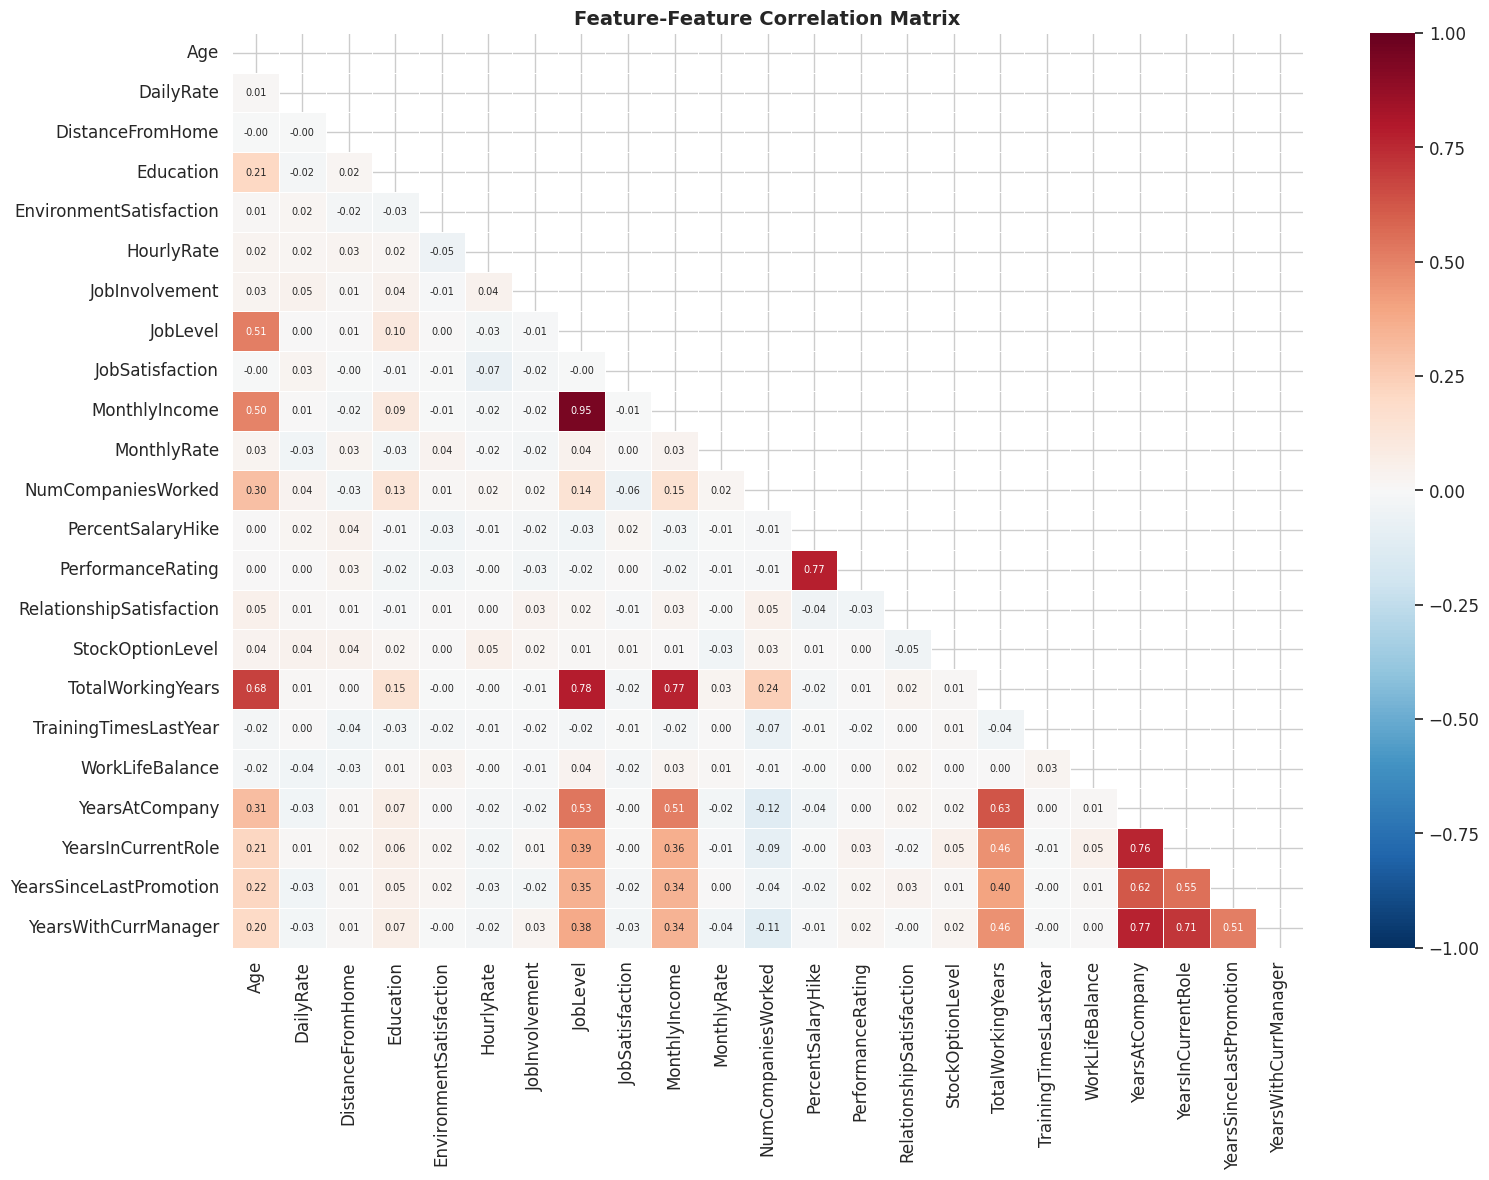

In [0]:
# --- Full heatmap ---
fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={"size": 7}
)
ax.set_title("Feature-Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. OverTime Deep Dive (Strongest Known Signal)

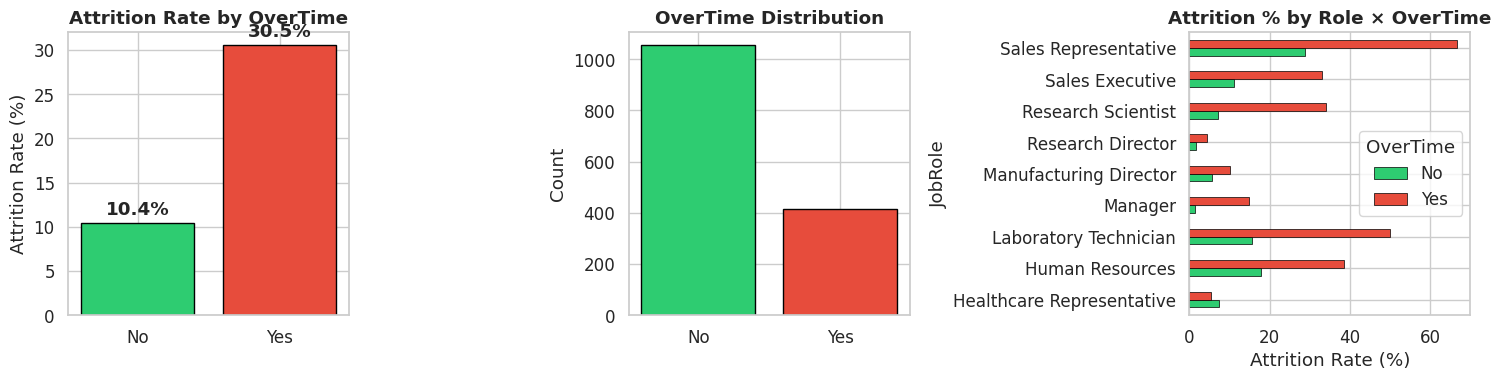

In [0]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Attrition rate by OverTime
ot_rates = df.groupby("OverTime")["Attrition_Flag"].mean() * 100
axes[0].bar(ot_rates.index, ot_rates.values, color=["#2ecc71", "#e74c3c"], edgecolor="black")
for i, v in enumerate(ot_rates.values):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
axes[0].set_title("Attrition Rate by OverTime", fontweight="bold")
axes[0].set_ylabel("Attrition Rate (%)")

# OverTime distribution
ot_counts = df["OverTime"].value_counts()
axes[1].bar(ot_counts.index, ot_counts.values, color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[1].set_title("OverTime Distribution", fontweight="bold")
axes[1].set_ylabel("Count")

# OverTime × JobRole
ot_role = df.groupby(["JobRole", "OverTime"])["Attrition_Flag"].mean().unstack() * 100
ot_role.plot(kind="barh", ax=axes[2], color=["#2ecc71", "#e74c3c"], edgecolor="black", linewidth=0.5)
axes[2].set_title("Attrition % by Role × OverTime", fontweight="bold")
axes[2].set_xlabel("Attrition Rate (%)")
axes[2].legend(title="OverTime")

plt.tight_layout()
plt.show()

## 9. Income Analysis

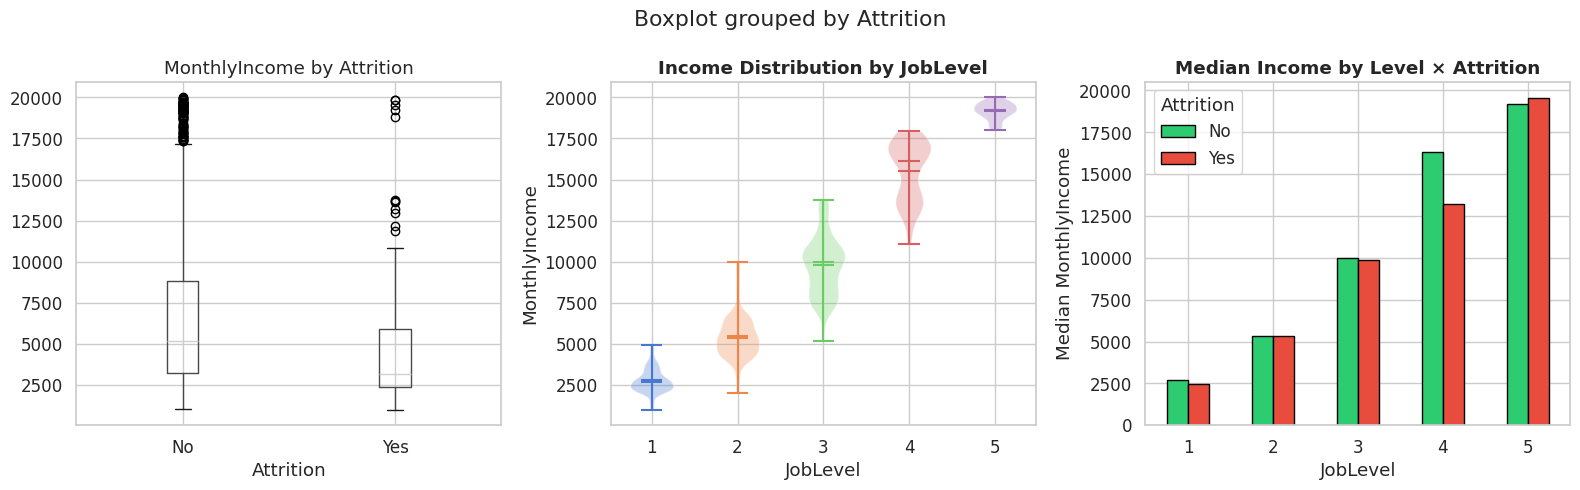


Mann-Whitney U test (MonthlyIncome ~ Attrition): U=100620, p=0.000000
Median income — Left: $3,202  |  Stayed: $5,204


In [0]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Income by attrition (box plot)
df.boxplot(column="MonthlyIncome", by="Attrition", ax=axes[0])
axes[0].set_title("MonthlyIncome by Attrition", fontweight="bold")
axes[0].set_xlabel("Attrition")
plt.sca(axes[0])
plt.title("MonthlyIncome by Attrition")

# Income by JobLevel (violin)
for level in sorted(df["JobLevel"].unique()):
    subset = df[df["JobLevel"] == level]["MonthlyIncome"]
    axes[1].violinplot(subset, positions=[level], showmeans=True, showmedians=True)
axes[1].set_xlabel("JobLevel")
axes[1].set_ylabel("MonthlyIncome")
axes[1].set_title("Income Distribution by JobLevel", fontweight="bold")
axes[1].set_xticks(sorted(df["JobLevel"].unique()))

# Income by attrition AND JobLevel
income_pivot = df.groupby(["JobLevel", "Attrition"])["MonthlyIncome"].median().unstack()
income_pivot.plot(kind="bar", ax=axes[2], color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[2].set_title("Median Income by Level × Attrition", fontweight="bold")
axes[2].set_ylabel("Median MonthlyIncome")
axes[2].legend(title="Attrition")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# Mann-Whitney U test
inc_yes = df[df["Attrition"] == "Yes"]["MonthlyIncome"]
inc_no = df[df["Attrition"] == "No"]["MonthlyIncome"]
u_stat, p_val = stats.mannwhitneyu(inc_yes, inc_no, alternative="two-sided")
print(f"\nMann-Whitney U test (MonthlyIncome ~ Attrition): U={u_stat:.0f}, p={p_val:.6f}")
print(f"Median income — Left: ${inc_yes.median():,.0f}  |  Stayed: ${inc_no.median():,.0f}")


## 10. Tenure & Experience Analysis

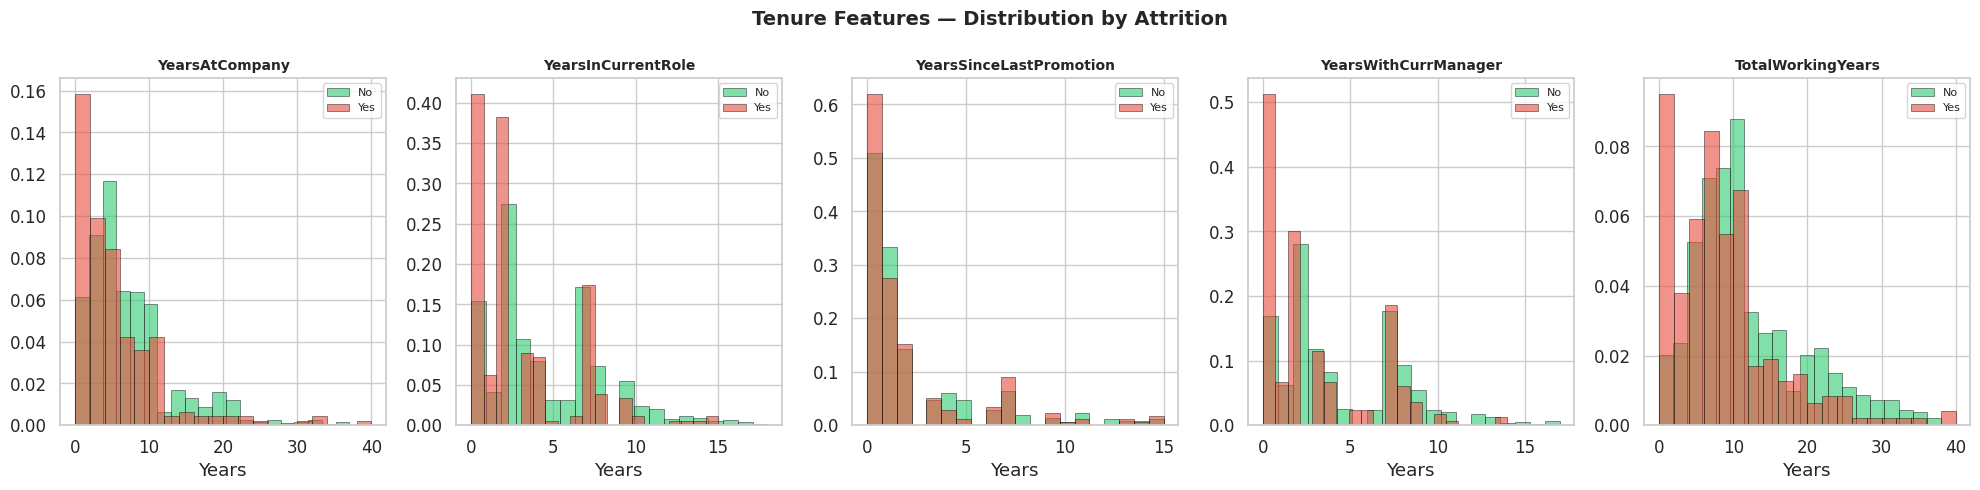

In [0]:
tenure_cols = ["YearsAtCompany", "YearsInCurrentRole", "YearsSinceLastPromotion", "YearsWithCurrManager", "TotalWorkingYears"]

fig, axes = plt.subplots(1, len(tenure_cols), figsize=(20, 5))

for i, col in enumerate(tenure_cols):
    ax = axes[i]
    for label, color in [("No", "#2ecc71"), ("Yes", "#e74c3c")]:
        subset = df[df["Attrition"] == label][col]
        ax.hist(subset, bins=20, alpha=0.6, label=label, color=color, density=True, edgecolor="black", linewidth=0.5)
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel("Years")

plt.suptitle("Tenure Features — Distribution by Attrition", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 11. Summary — EDA Findings & Pipeline Decisions

In [0]:
print("=" * 80)
print("EDA SUMMARY — IBM HR ATTRITION DATASET")
print("=" * 80)

# --- 1. Dataset shape & quality ---
n_rows, n_cols = df.shape
n_nulls = df.isnull().sum().sum()
n_dupes = df.duplicated().sum()
attrition_rate = df["Attrition_Flag"].mean() * 100
attrition_yes = df["Attrition_Flag"].sum()
attrition_no = len(df) - attrition_yes

print(f"\n📊 DATASET PROFILE")
print(f"   Rows: {n_rows}  |  Columns: {n_cols}")
print(f"   Nulls: {n_nulls}  |  Duplicates: {n_dupes}")
print(f"   Target: Attrition  →  Yes={attrition_yes} ({attrition_rate:.1f}%)  |  No={attrition_no} ({100 - attrition_rate:.1f}%)")

# --- 2. Constant / useless columns ---
constant_cols_summary = [
    col for col in df.columns if df[col].nunique() <= 1
    or (df[col].nunique() == 2 and df[col].dtype == "object" and df[col].value_counts().iloc[1] / len(df) < 0.01)
]
id_cols = ["EmployeeNumber"]
drop_cols = constant_cols_summary + id_cols

print(f"\n🗑️  COLUMNS TO DROP IN SILVER ({len(drop_cols)} total)")
for col in drop_cols:
    reason = "constant" if df[col].nunique() <= 1 else ("near-constant" if col in constant_cols_summary else "ID column")
    print(f"   • {col:25s}  unique={df[col].nunique():>4d}  reason={reason}  value={df[col].mode()[0]}")

# --- 3. Strongest numeric signals ---
print(f"\n📈 NUMERIC FEATURES — CORRELATION WITH ATTRITION (top 10)")
print(f"   {'Feature':35s} {'Correlation':>12s} {'|r|':>8s} {'p-value':>12s} {'Significant':>12s}")
print(f"   {'-'*82}")

corr_sorted = corr_df.sort_values("abs_corr", ascending=False).head(10)
for _, row in corr_sorted.iterrows():
    sig_marker = "✅ YES" if row["significant"] else "❌ no"
    print(f"   {row['feature']:35s} {row['correlation']:>+12.4f} {row['abs_corr']:>8.4f} {row['p_value']:>12.6f} {sig_marker:>12s}")

# --- 4. Weakest numeric signals ---
print(f"\n📉 WEAK / NO SIGNAL FEATURES (|r| < 0.03)")
weak_features = corr_df[corr_df["abs_corr"] < 0.03]
if len(weak_features) > 0:
    for _, row in weak_features.iterrows():
        print(f"   • {row['feature']:35s}  r={row['correlation']:+.4f}  → consider dropping in Gold")
else:
    weak_features = corr_df.sort_values("abs_corr").head(5)
    for _, row in weak_features.iterrows():
        print(f"   • {row['feature']:35s}  r={row['correlation']:+.4f}")

# --- 5. Categorical feature significance ---
print(f"\n🏷️  CATEGORICAL FEATURES — CHI-SQUARED TEST")
print(f"   {'Feature':30s} {'Chi2':>10s} {'p-value':>12s} {'Cramers V':>10s} {'Significant':>12s}")
print(f"   {'-'*78}")

cat_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df["Attrition"])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k)) if k > 0 else 0
    cat_results.append({"feature": col, "chi2": chi2, "p_value": p, "cramers_v": cramers_v})

cat_results_df = pd.DataFrame(cat_results).sort_values("cramers_v", ascending=False)
for _, row in cat_results_df.iterrows():
    sig = "✅ YES" if row["p_value"] < 0.05 else "❌ no"
    print(f"   {row['feature']:30s} {row['chi2']:10.2f} {row['p_value']:12.6f} {row['cramers_v']:10.3f} {sig:>12s}")

# --- 6. Highest attrition categories ---
print(f"\n🔴 HIGHEST ATTRITION CATEGORIES")
for col in cat_cols:
    grouped = df.groupby(col)["Attrition_Flag"].agg(["mean", "count"]).reset_index()
    grouped.columns = [col, "attrition_rate", "count"]
    worst = grouped.sort_values("attrition_rate", ascending=False).iloc[0]
    if worst["attrition_rate"] > df["Attrition_Flag"].mean():
        print(f"   {col:30s} → worst: {worst[col]:25s}  attrition={worst['attrition_rate']*100:.1f}%  (n={int(worst['count'])})")

# --- 7. Multicollinearity ---
print(f"\n🔗 MULTICOLLINEARITY — PAIRS WITH |r| > 0.7")
if len(high_corr_pairs) > 0:
    for a, b, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
        action = "→ DROP ONE" if abs(r) > 0.9 else "→ monitor"
        print(f"   {a:30s} ↔ {b:30s}  r={r:+.3f}  {action}")
else:
    print("   None found.")

# --- 8. OverTime breakdown ---
ot_rates = df.groupby("OverTime")["Attrition_Flag"].mean() * 100
print(f"\n⏰ OVERTIME IMPACT")
for val, rate in ot_rates.items():
    n = (df["OverTime"] == val).sum()
    print(f"   OverTime={val:5s}  →  attrition={rate:.1f}%  (n={n})")

# --- 9. Income breakdown ---
inc_yes = df[df["Attrition"] == "Yes"]["MonthlyIncome"]
inc_no = df[df["Attrition"] == "No"]["MonthlyIncome"]
print(f"\n💰 INCOME SUMMARY")
print(f"   Left (Yes):   median=${inc_yes.median():>8,.0f}  mean=${inc_yes.mean():>8,.0f}")
print(f"   Stayed (No):  median=${inc_no.median():>8,.0f}  mean=${inc_no.mean():>8,.0f}")
print(f"   Gap:          median=${inc_no.median() - inc_yes.median():>8,.0f}  (stayed earn more)")

# --- 10. Pipeline decisions ---
n_features_after_drop = n_cols - len(drop_cols) - 1  # -1 for target
strong_numeric = corr_df[corr_df["abs_corr"] > 0.1]["feature"].tolist()
strong_categorical = cat_results_df[cat_results_df["p_value"] < 0.05]["feature"].tolist()

print(f"\n🏗️  PIPELINE DECISIONS")
print(f"   SILVER LAYER:")
print(f"     • Drop {len(drop_cols)} columns: {drop_cols}")
print(f"     • Remaining features: {n_features_after_drop}")
print(f"     • Cast types: OverTime/Gender/Attrition → binary flags")
print(f"     • No null imputation needed (0 nulls)")

print(f"\n   GOLD LAYER — FEATURE ENGINEERING:")
print(f"     • Strong numeric signals ({len(strong_numeric)}): {strong_numeric}")
print(f"     • Strong categorical signals ({len(strong_categorical)}): {strong_categorical}")
print(f"     • Engineered features to create:")
print(f"       - income_per_year       = MonthlyIncome / (TotalWorkingYears + 1)")
print(f"       - promo_stagnation      = YearsSinceLastPromotion / (YearsAtCompany + 1)")
print(f"       - career_ratio          = TotalWorkingYears / Age")
print(f"       - avg_satisfaction       = (EnvironmentSatisfaction + JobSatisfaction + RelationshipSatisfaction) / 3")
print(f"       - is_early_career       = 1 if TotalWorkingYears <= 3")
print(f"       - overtime_flag         = 1 if OverTime = Yes")

collinear_to_drop = [a for a, b, r in high_corr_pairs if abs(r) > 0.9]
if collinear_to_drop:
    print(f"     • Drop for collinearity: {list(set(collinear_to_drop))}")

print(f"\n   ML NOTES:")
print(f"     • Class imbalance: {attrition_rate:.1f}% positive → use class_weight='balanced'")
print(f"     • Use stratified train/test split")
print(f"     • One-hot encode: {[c for c in cat_cols if c != 'OverTime']}")
print(f"     • Baseline to beat: majority-class accuracy = {100 - attrition_rate:.1f}%")

print(f"\n{'=' * 80}")
print(f"END OF EDA — PROCEED TO BRONZE INGESTION")
print(f"{'=' * 80}")

EDA SUMMARY — IBM HR ATTRITION DATASET

📊 DATASET PROFILE
   Rows: 1470  |  Columns: 36
   Nulls: 0  |  Duplicates: 0
   Target: Attrition  →  Yes=237 (16.1%)  |  No=1233 (83.9%)

🗑️  COLUMNS TO DROP IN SILVER (4 total)
   • EmployeeCount              unique=   1  reason=constant  value=1
   • Over18                     unique=   1  reason=constant  value=Y
   • StandardHours              unique=   1  reason=constant  value=80
   • EmployeeNumber             unique=1470  reason=ID column  value=1

📈 NUMERIC FEATURES — CORRELATION WITH ATTRITION (top 10)
   Feature                              Correlation      |r|      p-value  Significant
   ----------------------------------------------------------------------------------
   TotalWorkingYears                        -0.1711   0.1711     0.000000        ✅ YES
   JobLevel                                 -0.1691   0.1691     0.000000        ✅ YES
   YearsInCurrentRole                       -0.1605   0.1605     0.000000        ✅ YES
   Mon